problem statement
 Predict the house price based on house features.

Possible input features:

house size (sq ft)

number of bedrooms

number of bathrooms

location

age of house

In [2]:
#import liberies
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [33]:
df =pd.read_csv("House_price.csv")
df.head()

,area,bedrooms,bathrooms,age,price
0,1200,2,1,10,200000
1,1500,3,2,8,250000
2,1800,3,2,6,300000
3,2000,4,3,5,350000
4,2200,4,3,4,370000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       10 non-null     int64
 1   bedrooms   10 non-null     int64
 2   bathrooms  10 non-null     int64
 3   age        10 non-null     int64
 4   price      10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [35]:
df.describe()


,area,bedrooms,bathrooms,age,price
count,10.0000,10.000000,10.000000,10.000000,10.000000
mean,2360.0000,4.100000,3.100000,4.100000,396000.000000
std,753.0678,1.197219,1.197219,3.142893,126068.764305
min,1200.0000,2.000000,1.000000,1.000000,200000.000000
25%,1850.0000,3.250000,2.250000,1.250000,312500.000000
50%,2350.0000,4.000000,3.000000,3.500000,395000.000000
75%,2925.0000,5.000000,4.000000,5.750000,487500.000000
max,3500.0000,6.000000,5.000000,10.000000,600000.000000


In [36]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'age', 'price'], dtype='object')

NOw started the EDA

In [37]:
#try to see the missing values
df.isnull().sum()
#as we can see there are no missing valur 

area         0
bedrooms     0
bathrooms    0
age          0
price        0
dtype: int64

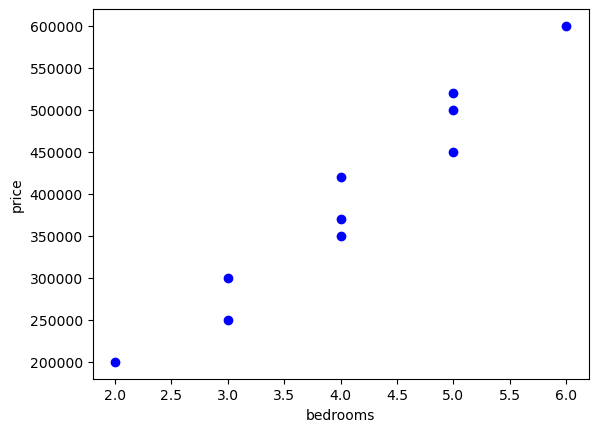

In [52]:
#now move to Data distribution
plt.scatter(df["bedrooms"],df["price"],color='blue')
plt.xlabel('bedrooms')
plt.ylabel('price')
plt.show()

Text(0, 0.5, 'price')

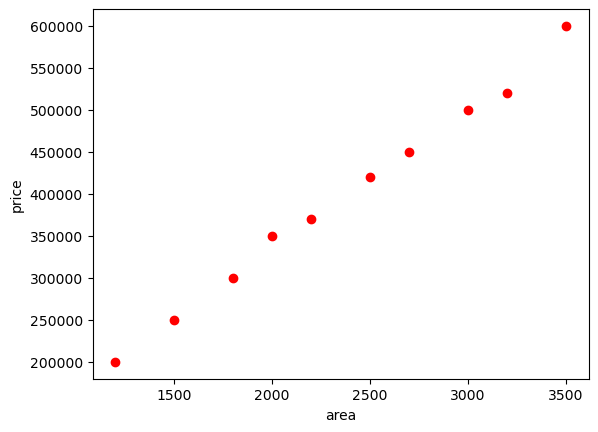

In [53]:
plt.scatter(df["area"],df["price"],color='red')

plt.xlabel('area')
plt.ylabel('price')

Text(0, 0.5, 'price')

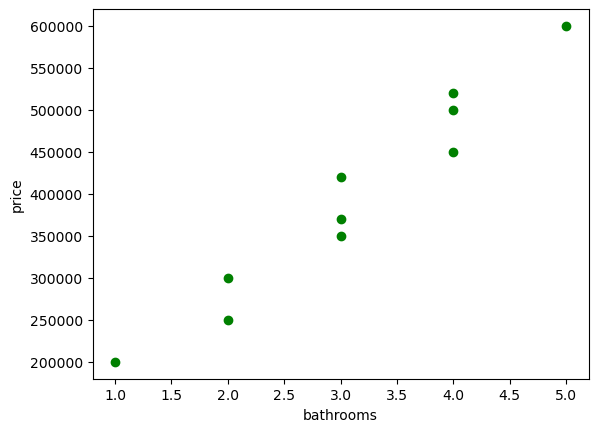

In [54]:
plt.scatter(df["bathrooms"],df["price"],color='green')
plt.xlabel('bathrooms')
plt.ylabel('price')

Text(0, 0.5, 'price')

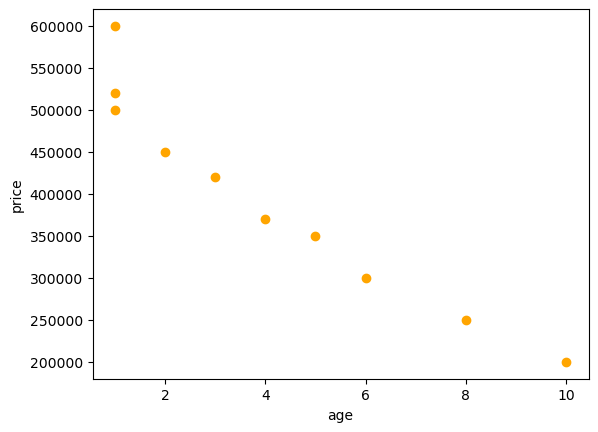

In [56]:
plt.scatter(df["age"],df["price"] ,color='orange')
plt.xlabel('age')
plt.ylabel('price')

In [57]:
#correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix)

               area  bedrooms  bathrooms       age     price
area       1.000000  0.966197   0.966197 -0.965199  0.997607
bedrooms   0.966197  1.000000   1.000000 -0.947893  0.974685
bathrooms  0.966197  1.000000   1.000000 -0.947893  0.974685
age       -0.965199 -0.947893  -0.947893  1.000000 -0.960744
price      0.997607  0.974685   0.974685 -0.960744  1.000000


In [60]:
#feature selection
# correlation with price

correlation = df.corr()["price"].abs().sort_values(ascending=False)
print(correlation)

X = df[["bedrooms", "area", "bathrooms", "age"]]
y = df["price"]







price        1.000000
area         0.997607
bedrooms     0.974685
bathrooms    0.974685
age          0.960744
Name: price, dtype: float64


In [61]:
#correlation between features
correlation_matrix = df.corr()
print(correlation_matrix)

               area  bedrooms  bathrooms       age     price
area       1.000000  0.966197   0.966197 -0.965199  0.997607
bedrooms   0.966197  1.000000   1.000000 -0.947893  0.974685
bathrooms  0.966197  1.000000   1.000000 -0.947893  0.974685
age       -0.965199 -0.947893  -0.947893  1.000000 -0.960744
price      0.997607  0.974685   0.974685 -0.960744  1.000000


In [62]:
#domain knowledge
# Based on domain knowledge, we can select features that are likely to have a significant impact on the price of a house.
X = df[["bedrooms", "area", "bathrooms", "age"]]
y = df["price"]
    

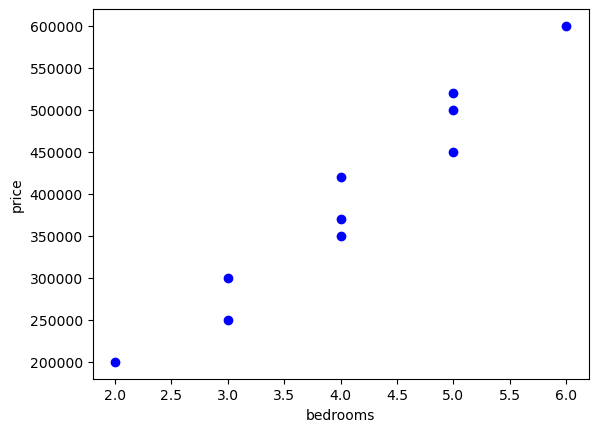

In [63]:
#visualization of the relationship between features and target variable
plt.scatter(df["bedrooms"], df["price"], color='blue')
plt.xlabel('bedrooms')
plt.ylabel('price')
plt.show()

In [64]:
#train and test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [66]:
#train the model
model = LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [67]:
#predict the test set
y_pred = model.predict(x_test)


In [69]:

#evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Absolute Error: 11791.801269912074
Mean Squared Error: 146761938.9588101
R-squared: 0.9919472187128225


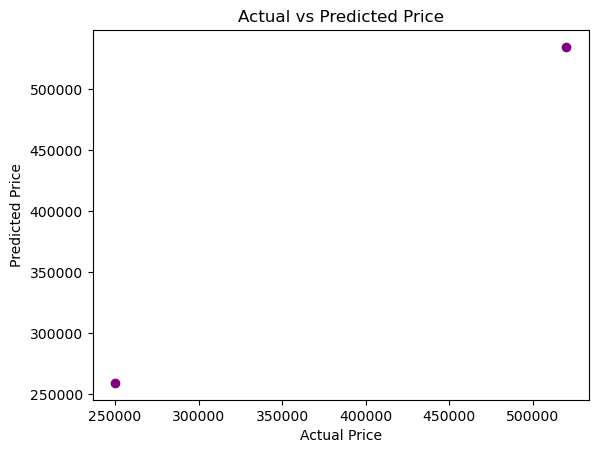

In [70]:
#predict value vs actual value
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()
